<a href="https://colab.research.google.com/github/sakharam-course/AI-CHATBOT-WITH-NLP/blob/main/Experiments%20and%20Mini-project/MLEXP_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Sakharam Bhaskar Sawant

Roll No : CS-50

Aim : To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

Task 1 : Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Task 2: Load Auto MPG Dataset

In [4]:

df = pd.read_csv("/auto-mpg (3).csv")

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


Task 3: Inspect and Clean Data

In [5]:
# Check information
print(df.info())

# Check missing values
print(df.isnull().sum())

# Replace '?' with NaN
df['horsepower'] = df['horsepower'].replace('?', np.nan)

# Convert horsepower to numeric
df['horsepower'] = pd.to_numeric(df['horsepower'])

# Remove missing values
df = df.dropna()

print("\nDataset after cleaning:")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Dataset after cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------  

Task 4: Select Horsepower and MPG

In [6]:
X = df['horsepower'].values
Y = df['mpg'].values

print("Horsepower:")
print(X[:5])

print("MPG:")
print(Y[:5])

Horsepower:
[130. 165. 150. 150. 140.]
MPG:
[18. 15. 18. 16. 17.]


Task 5: Plot Scatter Graph

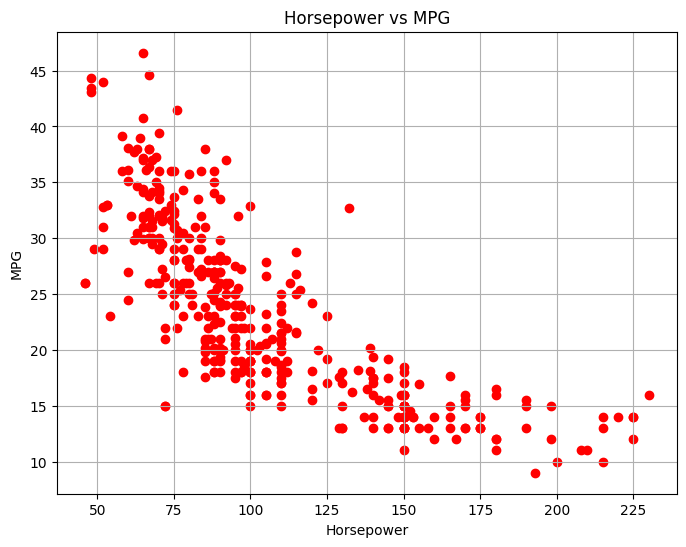

In [8]:
plt.figure(figsize=(8,6))
plt.scatter(X, Y, color='red')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.grid(True)
plt.show()

Task 6: Add Bias Term

In [9]:
# Add column of ones
X_bias = np.column_stack((np.ones(len(X)), X))

print(X_bias[:5])

[[  1. 130.]
 [  1. 165.]
 [  1. 150.]
 [  1. 150.]
 [  1. 140.]]


Task 7: Compute Correlation

In [10]:
correlation = np.corrcoef(X, Y)[0,1]

print("Correlation Coefficient =", correlation)

Correlation Coefficient = -0.7784267838977756


Task 8: Calculate OLS Weights

In [11]:
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y

print("Intercept =", weights[0])
print("Slope =", weights[1])

Intercept = 39.9358610211705
Slope = -0.15784473335365387


Task 9: Predict Values

In [12]:
Y_pred = X_bias @ weights

print("Predicted MPG:")
print(Y_pred[:5])

Predicted MPG:
[19.41604569 13.89148002 16.25915102 16.25915102 17.83759835]


Task 10: Compute Residuals

In [13]:
residuals = Y - Y_pred

print("Residuals:")
print(residuals[:5])

Residuals:
[-1.41604569  1.10851998  1.74084898 -0.25915102 -0.83759835]


Task 11: Calculate SSE, MSE, R²

In [14]:
SSE = np.sum(residuals**2)

MSE = np.mean(residuals**2)

SST = np.sum((Y - np.mean(Y))**2)

R2 = 1 - (SSE / SST)

print("SSE =", SSE)
print("MSE =", MSE)
print("R² =", R2)

SSE = 9385.915871932419
MSE = 23.943662938603108
R² = 0.6059482578894348


Task 12: Plot Regression And Residual Graph

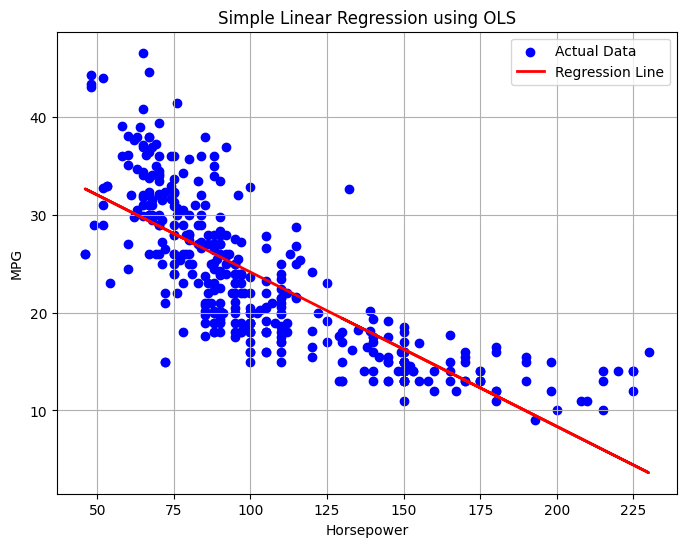

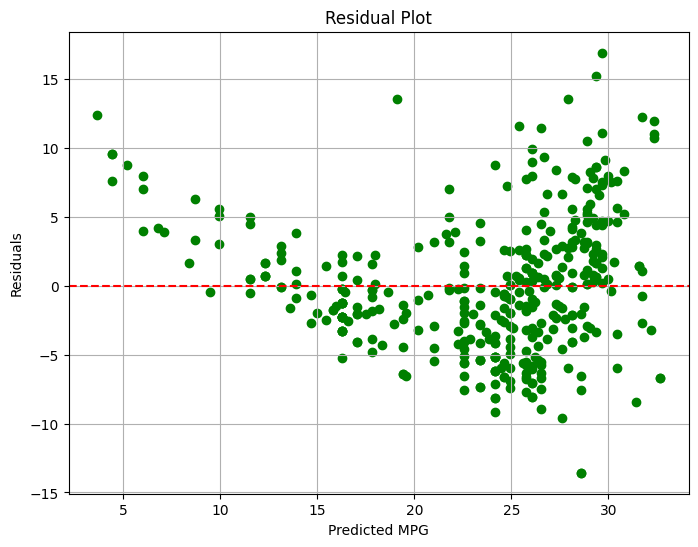

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(X, Y, color='blue', label='Actual Data')

plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')

plt.xlabel("Horsepower")

plt.ylabel("MPG")

plt.title("Simple Linear Regression using OLS")

plt.legend()

plt.grid(True)

plt.show()

plt.figure(figsize=(8,6))

plt.scatter(Y_pred, residuals, color='green')

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted MPG")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

Task 13: Interpret Results

1. The Simple Linear Regression model was successfully implemented using the Ordinary Least Squares (OLS) method to predict MPG (Miles Per Gallon) from horsepower.

2. The correlation coefficient indicated a negative relationship between horsepower and MPG, meaning that as the horsepower of a vehicle increases, its fuel efficiency generally decreases.
3. The OLS algorithm calculated the intercept and slope of the best-fit regression line, which was used to predict MPG values.
4. The predicted MPG values were found to be close to the actual values for many vehicles, indicating that the regression model fits the data reasonably well.
5. The residuals (difference between actual and predicted MPG) were analyzed to measure the prediction errors of the model.
6. The Sum of Squared Errors (SSE) represents the total squared prediction error. A lower SSE indicates a better-fitting regression model.
7. The Mean Squared Error (MSE) represents the average squared prediction error. A lower MSE indicates higher prediction accuracy.
8. The R² (Coefficient of Determination) measures how well the regression model explains the variation in MPG. A higher R² value indicates better model performance.
9. The regression plot showed a downward-sloping line, confirming the inverse relationship between horsepower and MPG.
10. The residual plot showed that the prediction errors were distributed around zero without a strong pattern, indicating that the linear regression model is appropriate for this dataset.
11. Overall, the results show that horsepower is an important factor affecting fuel efficiency, but other variables such as vehicle weight, engine displacement, acceleration, and the number of cylinders also influence MPG.
12. Therefore, the OLS-based Simple Linear Regression model provides a simple and effective method for predicting MPG from horsepower and serves as a good introduction to regression analysis in machine learning.